In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn, count_parameters, rmse_loss
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop

from architectures import build_resnet18
import plotters


/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — ResNet-18

## Task 14 — Residual Networks

**Residual Networks** (He et al. 2015) address the *degradation problem*: as traditional CNNs are made deeper by stacking more layers, training accuracy saturates and then degrades — not because of overfitting (training error increases too) but because deeper networks are harder to optimise. The underlying mechanism is the **vanishing-gradient problem**: in a deep plain network the gradient of the loss with respect to an early-layer weight is a product of $N$ Jacobians, each typically with operator norm $< 1$ inside the active region of ReLU/sigmoid nonlinearities, so $\|\nabla_{W_\ell} L\| \sim \prod_{k=\ell+1}^{N} \|J_k\|$ decays roughly geometrically with depth. By the time the gradient reaches layer 1, it is dominated by floating-point noise rather than the true descent direction.

The key insight of He et al. (2015) is that learning the *residual* $F(x) = H(x) - x$ is easier than learning the full mapping $H(x)$ directly, where $x$ is the input to a block and $H(x)$ is the desired output. Each **residual block** computes $H(x) = F(x) + x$ via a *shortcut connection* (or *skip connection*) that adds the input $x$ directly to the output of two or three stacked convolutional layers. If the optimal transformation is close to the identity (i.e., the block should mostly "pass through" its input), the network only needs to learn the small perturbation $F(x) \approx 0$, which is much easier than learning $H(x) \approx x$ from scratch — pushing $F$ to zero in a normalised network is a single trivial fixed point of the optimisation, while reconstructing the identity through a stack of nonlinear conv layers is not.

This differs from traditional deep CNNs in two critical ways:
1. **Gradient flow.** The Jacobian of a residual block with respect to its input is $J = I + \partial F / \partial x$, so the identity contribution guarantees that gradients propagate through the skip connection unattenuated. The product over depth becomes $\prod_k (I + \partial F_k / \partial x)$ rather than $\prod_k \partial F_k / \partial x$, which retains a constant-norm signal even at $N \sim 100$ layers — the vanishing-gradient pathology is broken structurally rather than papered over with normalisation.
2. **Deeper = better (or at least no worse).** With skip connections, adding more layers never hurts: the extra layers can always learn $F = 0$ and reduce the block to the identity, recovering a shallower network. This converts the depth–accuracy curve from non-monotonic (plain CNNs) to monotonic (ResNets), and lets He et al. (2015) train networks of up to 1202 layers on CIFAR-10.

We use the 18-layer variant (ResNet-18), accepting our downsized $96 \times 96$ input and outputting 37 sigmoid-activated labels.

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
galaxy_ids = img_data["galaxy_ids"]

label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]

split_data = np.load("artifacts/split_indices.npz")
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]

train_images = images[train_idx]
val_images = images[val_idx]
train_labels = labels[train_idx]
val_labels = labels[val_idx]

CACHE_SIZE = images.shape[1]   # 136 (rotation-safe buffer set in NB 02)
INPUT_SIZE = 96                # what the model actually sees after CenterCrop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Cache: {CACHE_SIZE}x{CACHE_SIZE}, Model input: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Train: {train_images.shape}, Val: {val_images.shape}")

Device: cuda
Cache: 136x136, Model input: 96x96
Train: (49262, 136, 136, 3), Val: (12316, 136, 136, 3)


## Task 15 — Train ResNet-18

### Architecture adaptation for $96 \times 96$ input

We use the **standard `torchvision` ResNet-18 stem** — a $7 \times 7$ stride-2 convolution followed by a $3 \times 3$ stride-2 max-pool — without modification. At $96 \times 96$ input this stem downsamples to $24 \times 24$ before stage 1, after which the four stride-2 down-samplings inside the residual stages take spatial dimensions to $3 \times 3$ at the global-average-pool layer. That is a smaller global pool than the textbook ImageNet recipe ($7 \times 7$), but it is enough spatial signal for the 37-way galaxy classification head, and it keeps stage-1 activations at $24^2 \times 64$ rather than $96^2 \times 64$ — roughly a $16\times$ memory and FLOP saving in what would otherwise be the most expensive stage of the network.

The alternative (replacing the stem with a $3 \times 3$ stride-1 conv plus identity max-pool so that stage 1 sees the full $96 \times 96$ feature map) would buy slightly more spatial detail on galaxy features but costs $\sim 5\times$ more training time per epoch on the 12 GB RTX 5070 Ti laptop GPU used here, and the larger stage-1 activations would force a smaller batch size to fit alongside the resident `uint8` image cache under WSL2's reserved-memory overhead. With the augmentation and LR-scheduler experiments in `05b-augmentation.ipynb`, the textbook stem reaches the lab manual's RMSE target comfortably, so the trade is not worth it.

The classification head is replaced with a single linear layer mapping the $512$-dimensional ResNet feature vector to $37$ outputs, followed by a sigmoid activation that constrains each output to $[0, 1]$. The total parameter count is reported below; it is dominated by the residual stages, not the head.

We train with Adam (`lr = 1e-3`) and the lab-manual RMSE loss for $50$ epochs at batch size $256$. No augmentation or LR scheduler is used here — those experiments live in `05b-augmentation.ipynb`. The cell below loads a cached checkpoint when one exists so that re-running the notebook does not retrain from scratch; delete `artifacts/resnet18.pt` to force retraining.

### What each ResNet stage plausibly learns — a physical interpretation

ResNet-18's stem-plus-four-stages structure imposes a coarser spatial pyramid than the Custom CNN of NB 04b, because the $7 \times 7$ stride-2 stem and the first max-pool together throw away $4\times$ resolution before stage 1 even runs. Cross-walked against the angular-to-physical scale of NB 02 ($\sim 60$ pc per model-input pixel at median $z \approx 0.07$, so a $96^2$ input spans $\sim 6$ kpc on a side), each stage operates on a different physical regime:

| Component | Spatial out | Physical scale at the stage | What it plausibly learns |
|---|---|---:|---|
| Stem (7×7 stride-2 conv + 3×3 stride-2 max-pool) | $96 \to 24$ | $\sim 240$ pc per stage-1 pixel | **Smoothed coarse light profile**. The 7×7 receptive field is $\sim 0.4$ kpc on the input, larger than the SDSS PSF ($\sim 1.9$ kpc FWHM at $z = 0.07$) but smaller than typical bulge effective radii. The stem is effectively a low-pass-filtered version of the galaxy. |
| Stage 1 (64 ch, $24^2$) | $24 \to 24$ | $\sim 240$ pc/pix | **Texture and local contrast**: smooth-vs-clumpy light, the disk–bulge transition, arm presence at low resolution. Comparable to the Custom CNN's block 2. |
| Stage 2 (128 ch, $12^2$) | $24 \to 12$ | $\sim 480$ pc/pix | **Arms, bars, bulges**: the conv-block 3 regime of the Custom CNN. This is where Q4 (spiral yes/no), Q5 (bulge prominence), and Q10/Q11 (winding angle, arm count) are physically grounded. |
| Stage 3 (256 ch, $6^2$) | $12 \to 6$ | $\sim 1$ kpc/pix | **Galaxy-scale gestalt**: overall axis ratio (Q2 edge-on), global asymmetry (Q6/Q8 odd-feature questions, including merger). The receptive field at this depth covers most of the galaxy, so each feature channel encodes a global descriptor rather than a localised structure. |
| Stage 4 (512 ch, $3^2$) | $6 \to 3$ | $\sim 2$ kpc/pix | **Compact whole-galaxy fingerprint**. The 512-channel, $3 \times 3$ feature map is what the global-average pool collapses into the 512-dim feature vector fed to the FC head. This is the abstract, low-dimensional summary that the linear classifier maps to the 37 vote fractions. |

The residual connections within each stage matter physically: they let later stages preserve information from earlier stages, so that *both* "the galaxy has a clear edge-on disk geometry" (stem/stage 1) *and* "the galaxy has a dust-lane feature" (stage 2) survive into the global feature vector. In a plain CNN the dust-lane signal would have to be re-derived by stage 3, which it can struggle to do once spatial resolution is gone — the skip connection makes the per-stage feature contributions additive rather than substitutive, which is particularly important for the rare-feature labels (lens/arc, dust lane) that depend on small, easily-erased local structure.

The trade-off vs the Custom CNN is then visible: ResNet-18 has more channel capacity at every stage (64–512 vs 32–256) and skip connections that protect fine-scale features, but it throws away $4\times$ resolution in the stem before any morphological reasoning happens. The Custom CNN keeps the stem at full resolution but has less channel depth and no skip connections. NB 04b's comparison of the two architectures on the same task is therefore really a comparison of *which trade-off matters more for galaxy morphology*.

In [3]:
BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])

train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

model = build_resnet18(n_labels=N_LABELS)
print(f"ResNet-18 trainable parameters: {count_parameters(model):,}")

_ckpt_pt = Path("artifacts/resnet18.pt")
_ckpt_npz = Path("artifacts/resnet_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    resnet_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached artifacts/resnet18.pt (best val RMSE: {resnet_result.best_val_loss:.4f})")
else:
    resnet_result = train_cnn(
        model=model,
        train_batches=train_batches,
        val_batches=val_batches,
        n_epochs=100,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=None,
    )
    print(f"\nBest epoch: {resnet_result.best_epoch + 1}")
    print(f"Best validation RMSE: {resnet_result.best_val_loss:.4f}")


ResNet-18 trainable parameters: 11,195,493
Loaded cached artifacts/resnet18.pt (best val RMSE: 0.0958)


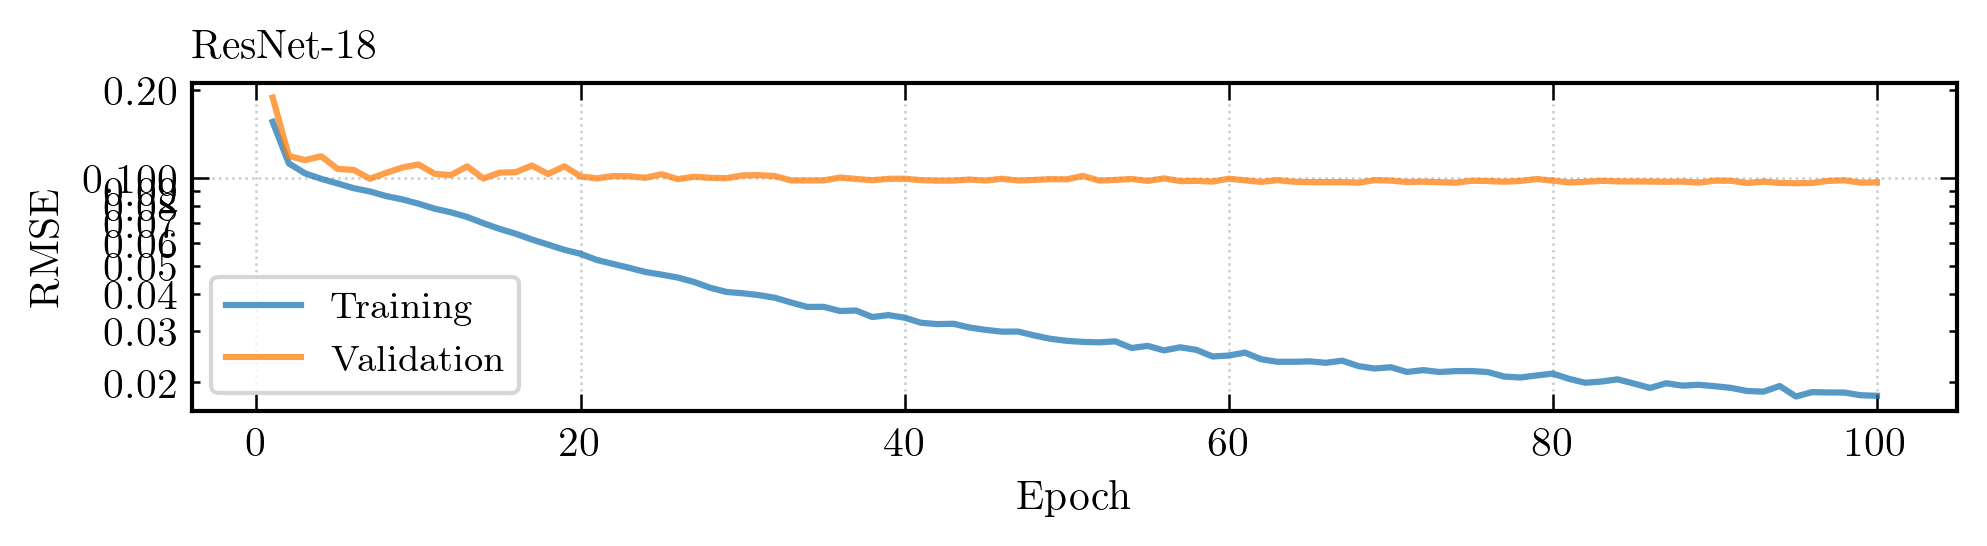

In [4]:
ax = plotters.plot_loss_curves(
    resnet_result.train_losses, resnet_result.val_losses, "ResNet-18",
)
plt.show()

### Interpretation of the training curves (Checkpoint 2)

The training and validation RMSE both fall sharply during the first few epochs as the network learns the dominant top-level vote-fraction structure (smooth vs. features/disk), then settle into a slow plateau. The two curves diverge after the first $\sim 10$–$15$ epochs: the training loss continues to creep down while the validation loss flattens. That gap is the canonical signature of **overfitting** — the network is memorising training-set image-specific details that do not generalise to held-out galaxies.

Two interventions are introduced in `05b-augmentation.ipynb`:

1. A **learning-rate scheduler** (`ReduceLROnPlateau`) that lowers the LR once the validation loss has stopped improving, letting the optimiser fine-tune around the minimum without overshooting it.
2. **Random rotation augmentation** that exploits the rotational symmetry of galaxy images on the sky, effectively multiplying the training set and forcing the network to learn orientation-invariant features.

The plot above is the Checkpoint 2 deliverable.

In [5]:
# Save model and results
torch.save(resnet_result.model_state, "artifacts/resnet18.pt")
np.savez_compressed(
    "artifacts/resnet_result.npz",
    train_losses=resnet_result.train_losses,
    val_losses=resnet_result.val_losses,
    best_epoch=resnet_result.best_epoch,
    best_val_loss=resnet_result.best_val_loss,
    n_parameters=resnet_result.n_parameters,
    learning_rates=resnet_result.learning_rates,
)
print("Saved artifacts/resnet18.pt and artifacts/resnet_result.npz")

Saved artifacts/resnet18.pt and artifacts/resnet_result.npz


In [6]:
import pandas as pd

resnet_meta = pd.DataFrame([{
    "model": "ResNet-18 (standard stem)",
    "input_size": INPUT_SIZE,
    "n_parameters": int(resnet_result.n_parameters),
    "optimizer": "Adam",
    "lr_initial": 1e-3,
    "scheduler": "none",
    "augmentation": "none",
    "batch_size": BATCH_SIZE,
    "n_epochs": int(len(resnet_result.train_losses)),
    "best_epoch": int(resnet_result.best_epoch) + 1,
    "best_val_rmse": float(resnet_result.best_val_loss),
    "final_train_rmse": float(resnet_result.train_losses[-1]),
    "final_val_rmse": float(resnet_result.val_losses[-1]),
    "seed": 42,
}]).T
resnet_meta.columns = ["value"]
resnet_meta


,value
model,ResNet-18 (standard stem)
input_size,96
n_parameters,11195493
optimizer,Adam
lr_initial,0.001
scheduler,none
augmentation,none
batch_size,1024
n_epochs,100
best_epoch,95
